<a href="https://colab.research.google.com/github/andrealoy/PathMNISTClassification/blob/main/pathmnist_classification_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.1 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/andrealoy/PathMNISTClassification.git

Cloning into 'PathMNISTClassification'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 30 (delta 12), reused 18 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 3.12 MiB | 19.15 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [3]:
%cd PathMNISTClassification

/content/PathMNISTClassification


In [4]:
%cd /content/PathMNISTClassification

/content/PathMNISTClassification


In [5]:
#%load_ext autoreload
#%autoreload 2
import medmnist
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm

In [6]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

In [7]:
# Activation de la seed pour rendre l'entraînement reproductible
# (initialisation des poids, shuffle des batches, etc.)

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

100%|██████████| 206M/206M [00:03<00:00, 64.3MB/s]


In [9]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [10]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [11]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [12]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


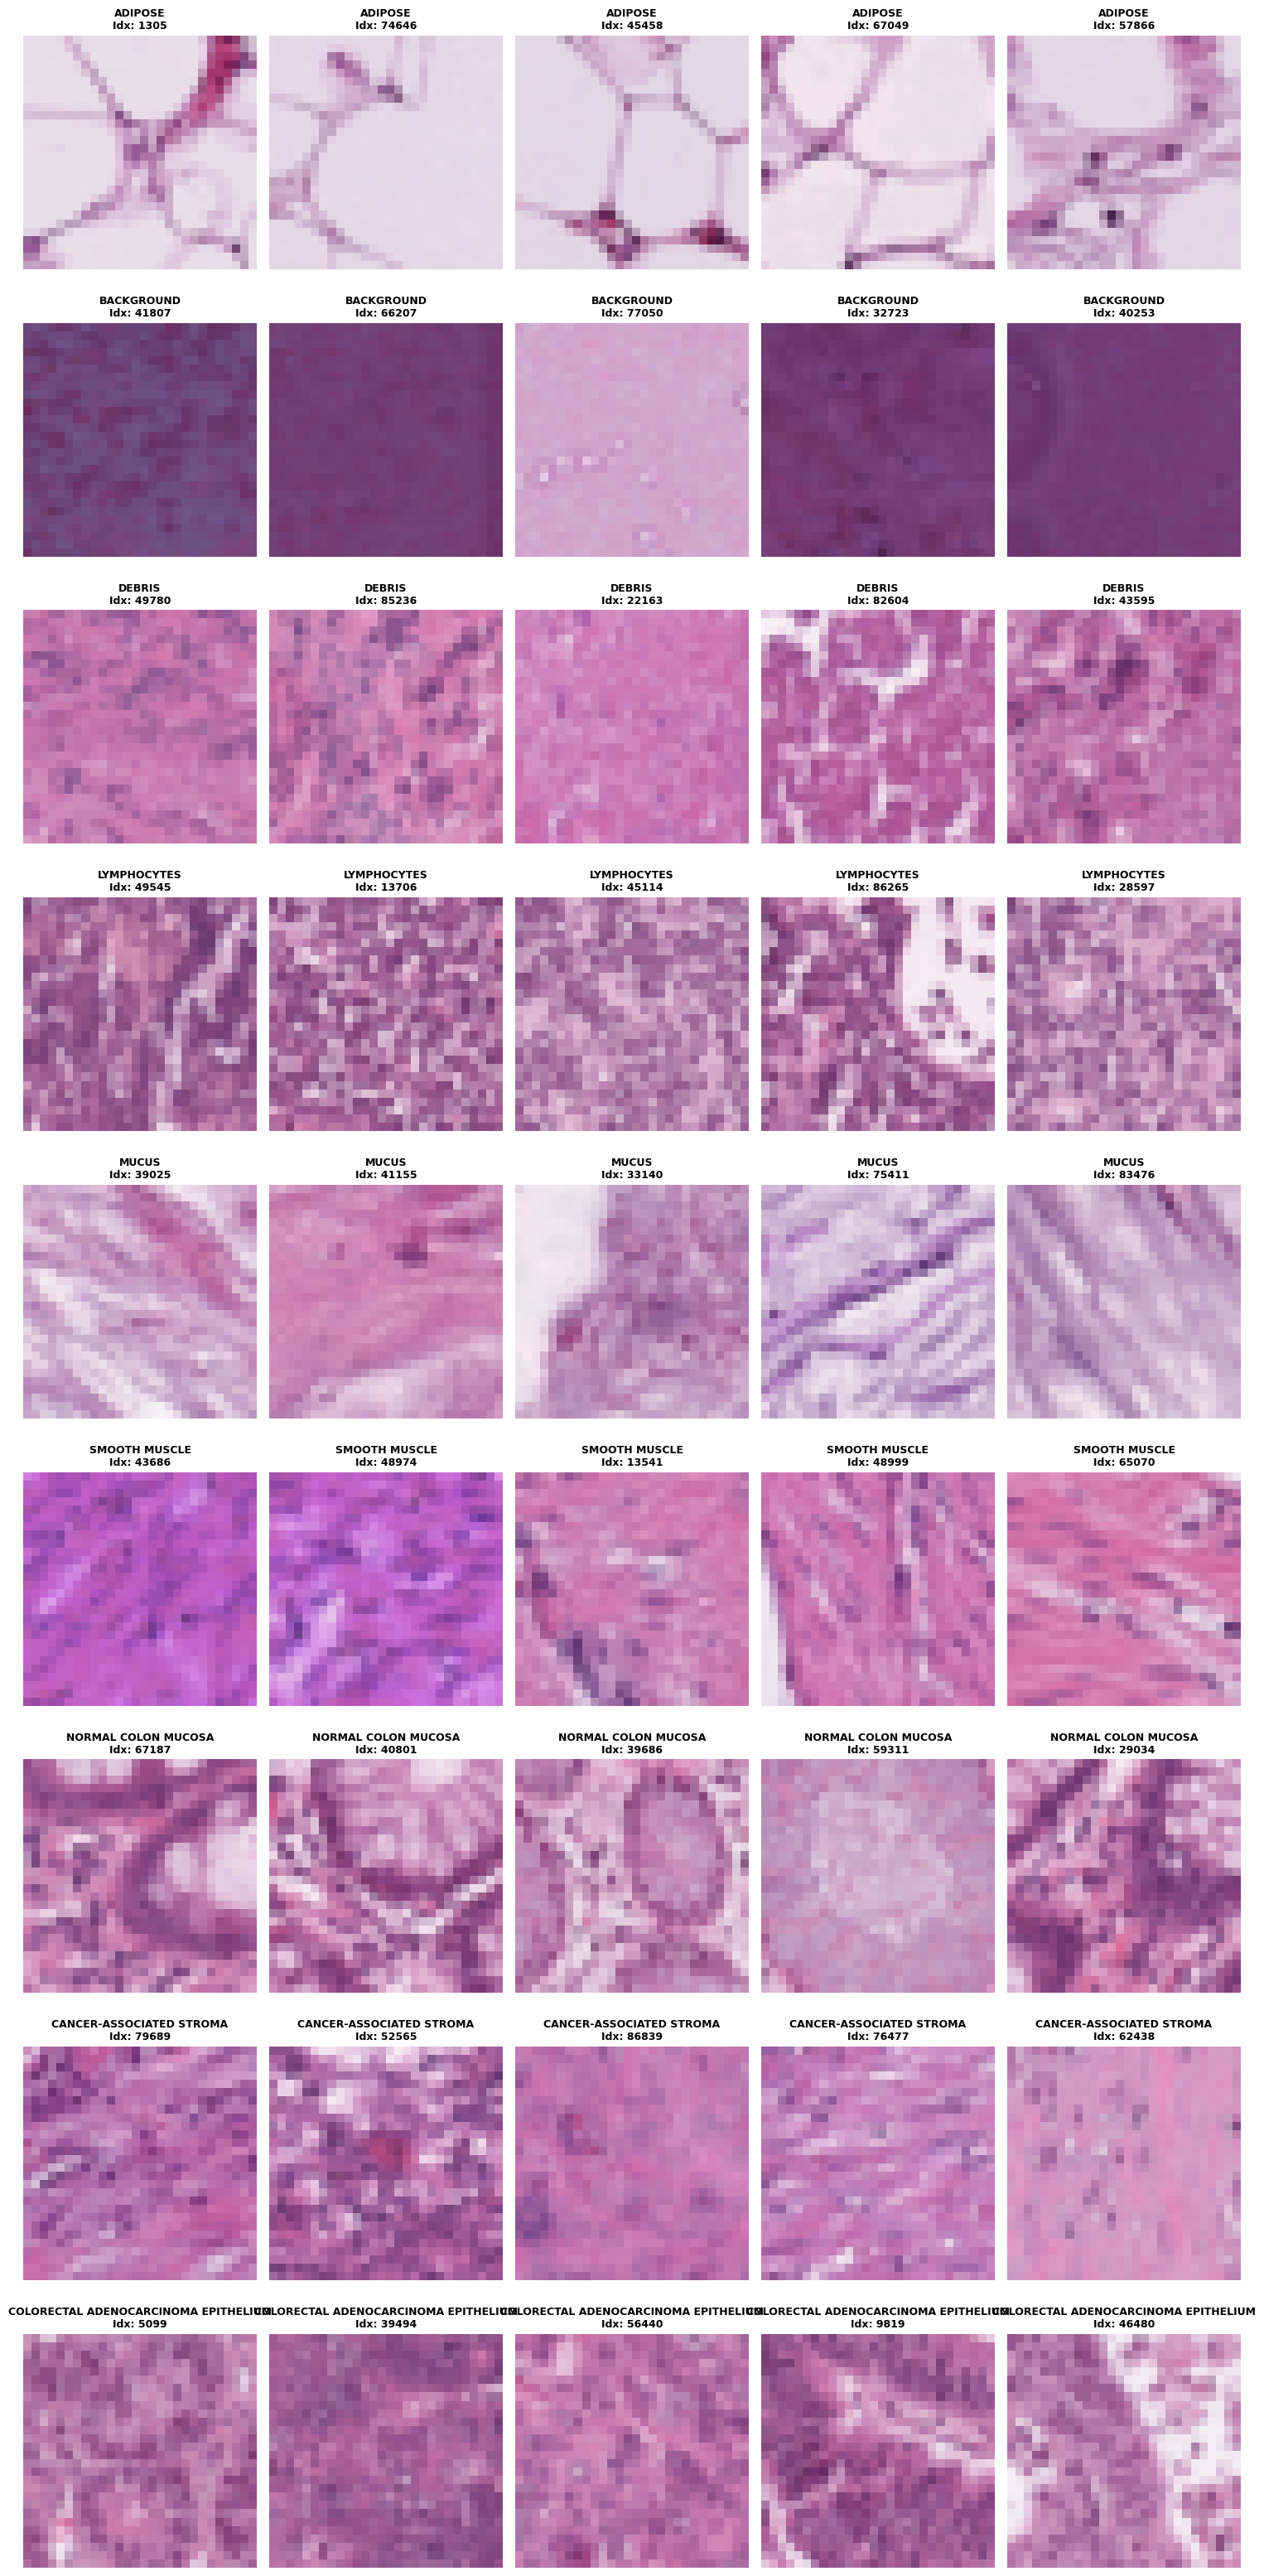

In [13]:
display_medmnist_samples(dataset,"*",5)

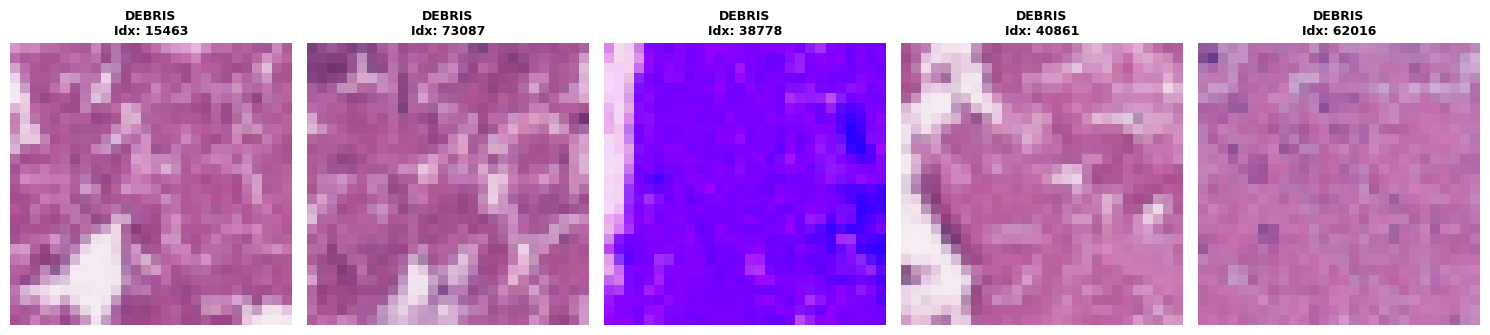

In [14]:
display_medmnist_samples(dataset,"debris",5)

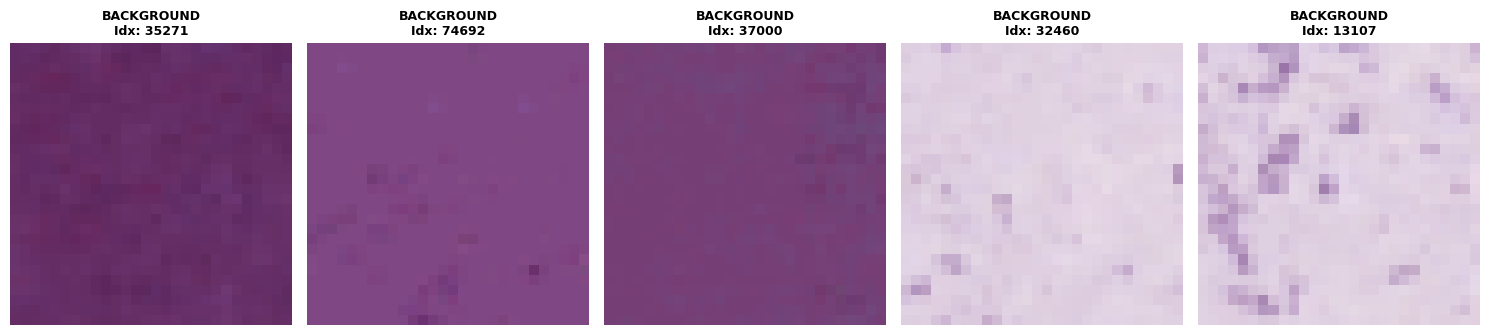

In [15]:
display_medmnist_samples(dataset,"background",5)

In [16]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [17]:
plot_class_distribution(dataset)

Les classes se distinguent principalement par leur niveau d’organisation structurelle (organisé vs désorganisé), leur densité cellulaire, et leur rôle biologique, ainsi les 9 classes peuvent etre réduites à 4 blocs logiques (tissu normal, cellule isolée, sécrétion ou pathologie).

En observant plusieurs images de la classe Debris et en les comparant avec celles de la classe Background, on remarque des différences visuelles nettes.

Les images de la classe Debris présentent généralement des fragments irréguliers et des structures plus hétérogènes. On y observe souvent une texture plus complexe, avec des amas de formes ou des contours marqués qui se détachent du reste de l’image. Les couleurs peuvent aussi varier davantage, avec des zones plus sombres ou plus denses.

À l’inverse, les images de la classe Background apparaissent plus uniformes et plus lisses. La texture est généralement plus homogène, avec peu de structures distinctes ou de contours marqués. Les couleurs sont aussi plus régulières, souvent dominées par des tons rosés ou violacés relativement constants.

Ainsi, les images Debris se caractérisent par des textures irrégulières et des motifs plus complexes, tandis que les images Background sont plus homogènes et moins structurées visuellement.

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


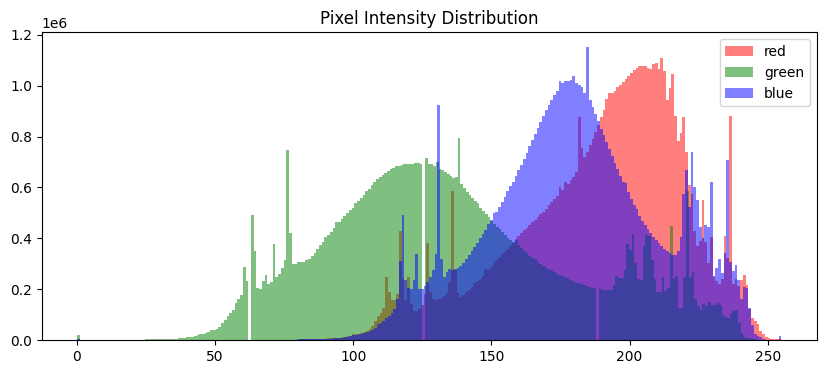

In [18]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Shape: (28, 28, 3)
Red   Channel -> Mean: 128.48 | Std: 10.92
Green Channel -> Mean: 71.84 | Std: 7.18
Blue  Channel -> Mean: 125.65 | Std: 9.77
Global Stats -> Min: 11 | Max: 139


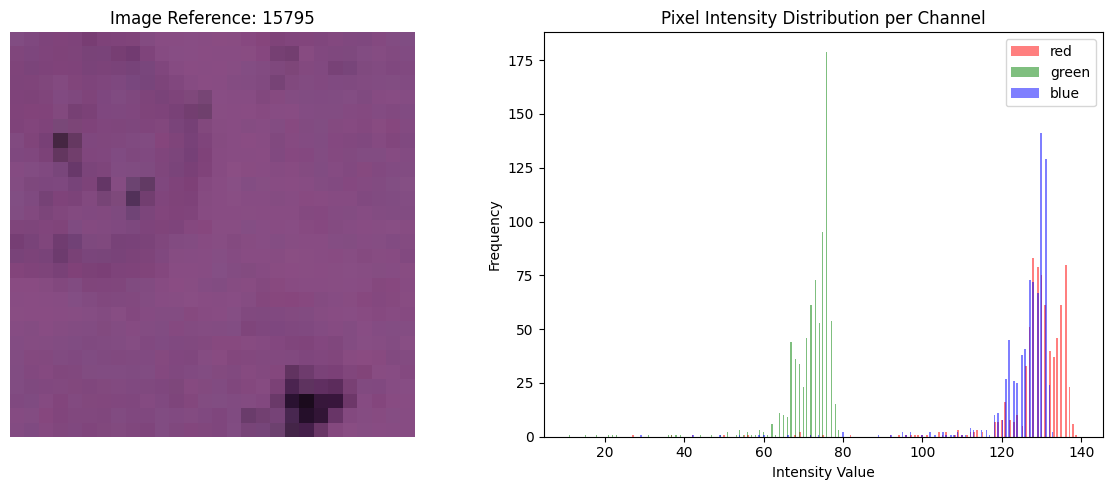

In [19]:
show_random_pixel_stats(dataset)

Nous avons calculé la moyenne et l’écart-type des intensités de pixels pour chaque canal RGB sur une image du jeu d’entraînement. Les valeurs obtenues sont différentes des statistiques d’ImageNet. Cela est attendu car les images du dataset PathMNIST sont des images histopathologiques avec des distributions de couleurs spécifiques (principalement des teintes roses et violettes dues à la coloration H&E), tandis qu’ImageNet contient des images naturelles avec une distribution de couleurs plus variée. Les statistiques de pixels ne sont donc pas proches de celles d’ImageNet.

+ nos pixels sont normalisés entre -1 et 1

alors que ImageNet est normalisé autour de 0-1 puis standardisé

# Preparing the data

In [20]:
# Simple Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [21]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [22]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        # First hidden layer + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Second hidden layer + ReLU + Dropout
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # Output layer
        x = self.fc3(x)
        return x


In [23]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [26]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Required for Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [27]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS, device)

Epoch 1/10: 100%|██████████| 704/704 [00:04<00:00, 152.58it/s, loss=1.23]


Summary Epoch 1: Val Loss: 1.3325 | Val Acc: 50.65%


Epoch 2/10: 100%|██████████| 704/704 [00:03<00:00, 176.37it/s, loss=1.18]


Summary Epoch 2: Val Loss: 1.2672 | Val Acc: 52.59%


Epoch 3/10: 100%|██████████| 704/704 [00:03<00:00, 178.40it/s, loss=1.35]


...

Summary Epoch 8: Val Loss: 1.2832 | Val Acc: 51.75%


Epoch 9/10: 100%|██████████| 704/704 [00:03<00:00, 176.67it/s, loss=1.13]


Summary Epoch 9: Val Loss: 1.2432 | Val Acc: 53.14%


Epoch 10/10: 100%|██████████| 704/704 [00:04<00:00, 174.17it/s, loss=1.4]


Summary Epoch 10: Val Loss: 1.2460 | Val Acc: 53.56%


Test accuracy: 0.13598602586882472


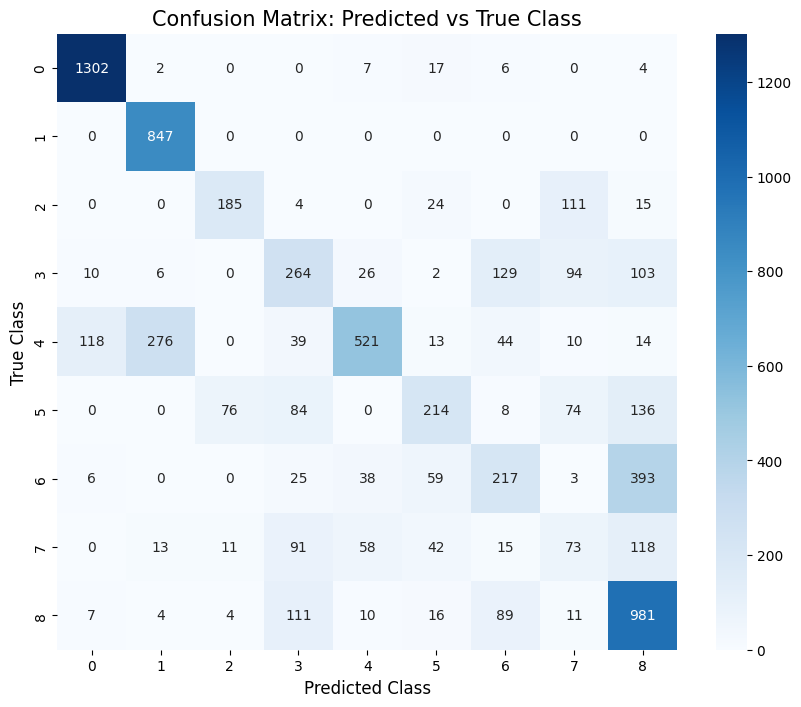

array([[1302,    2,    0,    0,    7,   17,    6,    0,    4],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  185,    4,    0,   24,    0,  111,   15],
       [  10,    6,    0,  264,   26,    2,  129,   94,  103],
       [ 118,  276,    0,   39,  521,   13,   44,   10,   14],
       [   0,    0,   76,   84,    0,  214,    8,   74,  136],
       [   6,    0,    0,   25,   38,   59,  217,    3,  393],
       [   0,   13,   11,   91,   58,   42,   15,   73,  118],
       [   7,    4,    4,  111,   10,   16,   89,   11,  981]])

In [28]:
# Évaluation sur l'ensemble de test (exigence de l'énoncé)
# La boucle d'entraînement affiche les métriques train/validation.
# Cette cellule calcule la performance finale sur le jeu de test
# (accuracy et matrice de confusion).

@torch.no_grad()
def eval_test(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    return acc


test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:", test_acc)

# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names)

In [29]:
 # Q2.1 — Affichage des valeurs exactes d'accuracy demandées dans l'énoncé
# L'exercice demande de reporter les performances à certaines étapes de l'entraînement
# (epoch 1, epoch 10 et epoch finale). On affiche ici les valeurs exactes stockées
# dans l'historique d'entraînement sans les arrondir.
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — epoch finale:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — epoch finale:", history["val_acc"][-1])

Train acc — epoch 1: 39.24063291701854
Train acc — epoch 10: 53.110138228365706
Train acc — epoch finale: 53.110138228365706
Val acc — epoch 1: 50.649740103958415
Val acc — epoch 10: 53.55857656937225
Val acc — epoch finale: 53.55857656937225


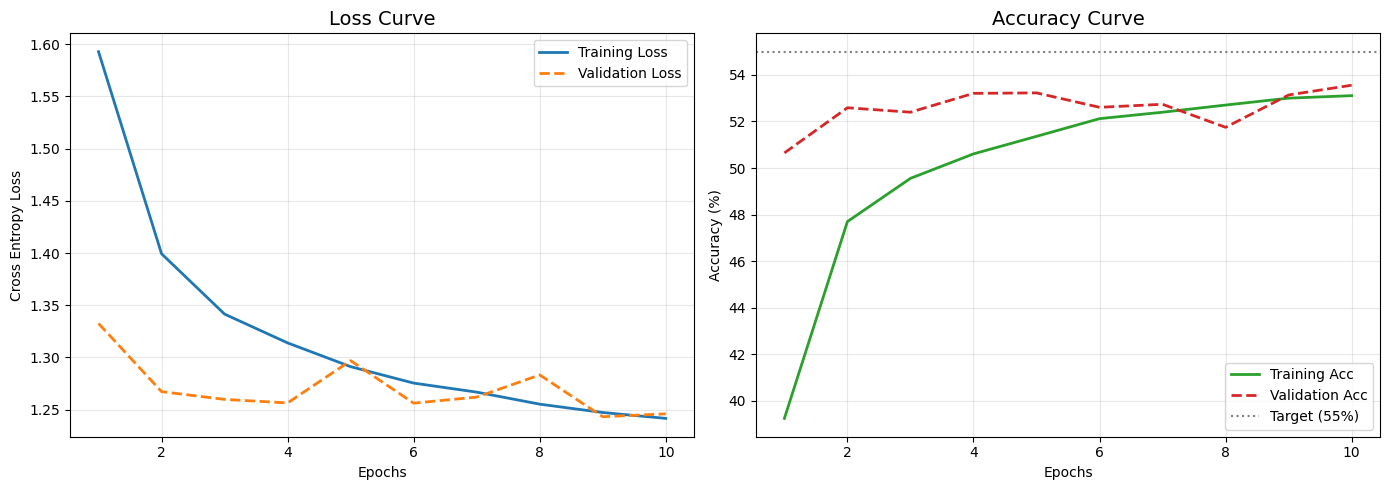

In [30]:
plot_training_history(history)

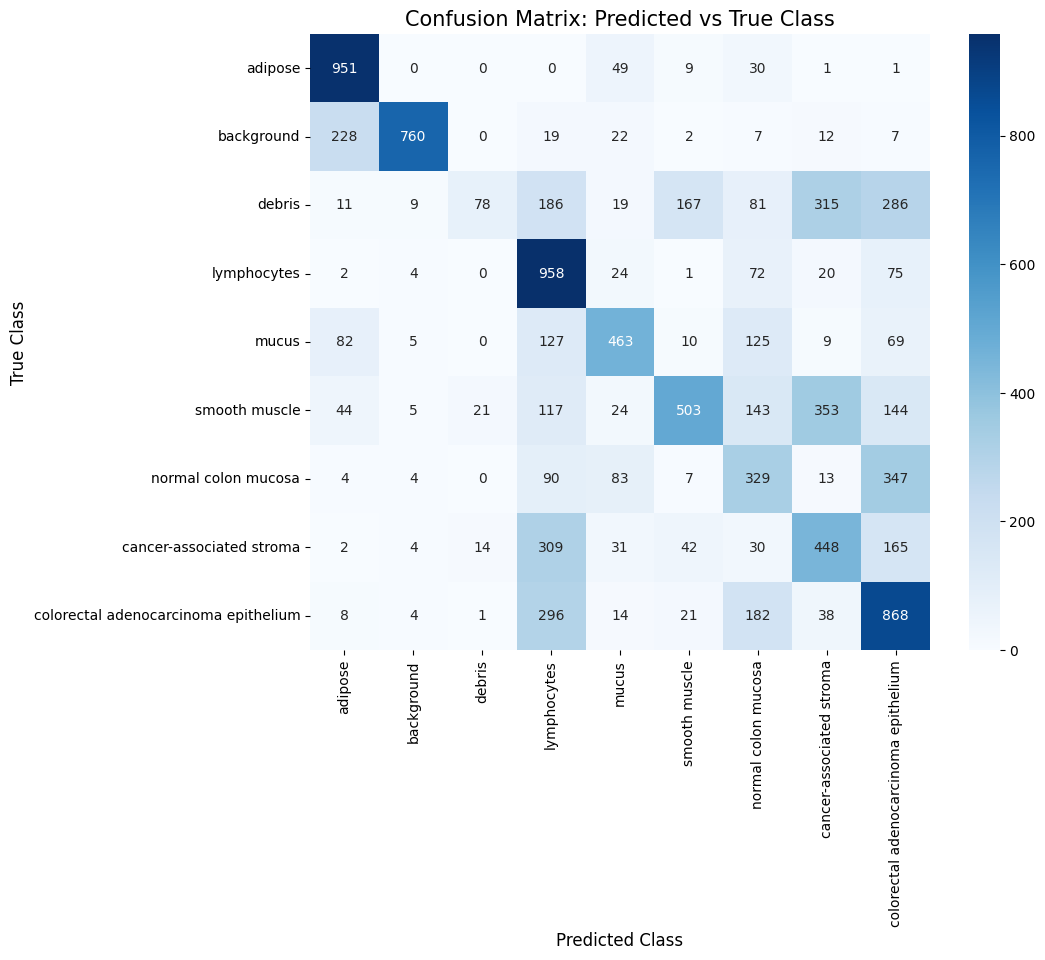

In [31]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [32]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [33]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 353 instances
True Class: smooth muscle (Index 5)
Predicted as: cancer-associated stroma (Index 7)


CNN

In [34]:
import torch.nn as nn
import torch.nn.functional as F

class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [35]:
# Q3.3 — Nombre total de paramètres entraînables
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Paramètres de la 1ère couche conv (block1[0])
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# Vérification avec PyTorch
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [36]:
# Q3.1 — entraînement du CNN sans data augmentation
model = cnn
EPOCHS = 40

In [37]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [38]:
# Q3.1 — entraîner le CNN sans data augmentation (40 epochs)

model = cnn
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=40,
    device=device
)

Epoch 1/40: 100%|██████████| 704/704 [00:05<00:00, 132.08it/s, loss=1.15]


Summary Epoch 1: Val Loss: 0.7385 | Val Acc: 73.69%


Epoch 2/40: 100%|██████████| 704/704 [00:04<00:00, 156.06it/s, loss=1.07]


Summary Epoch 2: Val Loss: 0.6123 | Val Acc: 79.62%


Epoch 3/40: 100%|██████████| 704/704 [00:04<00:00, 153.17it/s, loss=0.737]


...

Summary Epoch 38: Val Loss: 0.2410 | Val Acc: 92.12%


Epoch 39/40: 100%|██████████| 704/704 [00:04<00:00, 156.56it/s, loss=0.748]


Summary Epoch 39: Val Loss: 0.2582 | Val Acc: 91.35%


Epoch 40/40: 100%|██████████| 704/704 [00:04<00:00, 158.03it/s, loss=0.627]


Summary Epoch 40: Val Loss: 0.2707 | Val Acc: 91.07%


In [39]:
# Q3.1 — Premier epoch où l'écart (train_acc - val_acc) dépasse 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs commencent à 1
        break

print("Premier epoch avec gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc (exact):", history_cnn["train_acc"][i])
    print("Val acc (exact):", history_cnn["val_acc"][i])
    print("Gap (exact):", gaps[i])
else:
    print("Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.")

Premier epoch avec gap > 15: None
Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.


Nous avons entraîné le CNN pendant 40 epochs sans data augmentation et analysé l’évolution de l’accuracy sur les ensembles d’entraînement et de validation. Afin de détecter un éventuel overfitting, nous avons calculé la différence entre train_acc et val_acc à chaque epoch. Sur l’ensemble des 40 epochs, cet écart n’a jamais dépassé 15 points de pourcentage. Cela suggère que le modèle ne présente pas d'overfitting important dans cette configuration et qu’il généralise relativement bien sur les données de validation.

CNN TEST accuracy: 0.833008356545961


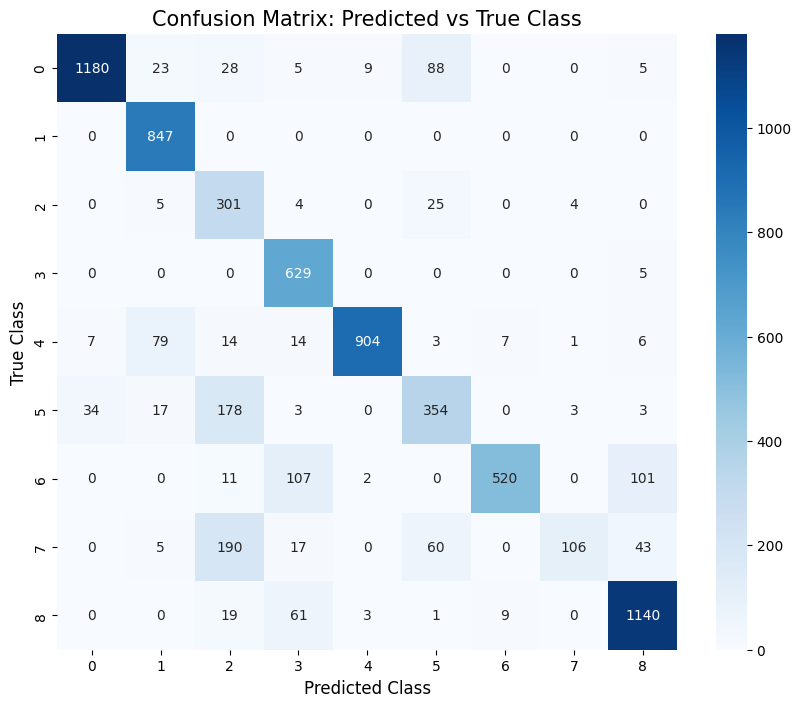

array([[1180,   23,   28,    5,    9,   88,    0,    0,    5],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    5,  301,    4,    0,   25,    0,    4,    0],
       [   0,    0,    0,  629,    0,    0,    0,    0,    5],
       [   7,   79,   14,   14,  904,    3,    7,    1,    6],
       [  34,   17,  178,    3,    0,  354,    0,    3,    3],
       [   0,    0,   11,  107,    2,    0,  520,    0,  101],
       [   0,    5,  190,   17,    0,   60,    0,  106,   43],
       [   0,    0,   19,   61,    3,    1,    9,    0, 1140]])

In [40]:
# Q3.2 — Évaluation finale sur le jeu de test (accuracy + matrice de confusion)

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred)
    return acc, cm

test_acc_cnn, test_cm_cnn = eval_test_acc(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

La matrice de confusion montre que la majorité des prédictions correctes se situent sur la diagonale, ce qui indique que le CNN classe correctement une grande partie des images du jeu de test. Certaines classes sont presque parfaitement reconnues, comme la classe 1 et la classe 3. Cependant, quelques confusions subsistent entre des classes visuellement proches, par exemple entre certaines images des classes 5 et 2 ou entre les classes 7 et 8. Globalement, les résultats montrent que le CNN capture mieux les structures spatiales des images que le modèle MLP utilisé précédemment, ce qui conduit à une amélioration significative des performances de classification

Les images histologiques n’ont pas d’orientation canonique : une coupe de tissu reste valide même si elle est tournée ou retournée. Une augmentation pertinente exploitant cette propriété est la rotation aléatoire (par exemple 90°, 180° ou 270°) ou les flip horizontaux et verticaux, car ces transformations ne modifient pas la structure biologique du tissu et permettent d’augmenter la diversité des données d’entraînement.

En revanche, certaines augmentations couramment utilisées pour les images naturelles peuvent être inadaptées pour l’histologie. Par exemple, un recadrage aléatoire agressif (random crop) peut supprimer des structures cellulaires importantes ou des motifs tissulaires essentiels pour la classification. Cela pourrait altérer l’information diagnostique contenue dans l’image et donc nuire à l’apprentissage du modèle.

Le CNN comporte 94 857 paramètres entraînables au total. Pour la première couche convolutionnelle, le nombre de paramètres peut être calculé avec la formule suivante :
out_channels × (in_channels × kH × kW + 1), où +1 correspond au biais associé à chaque filtre.

Dans notre modèle, la couche possède 32 filtres, 3 canaux d’entrée et un noyau de taille 3 × 3.
Le calcul est donc :
32 × (3 × 3 × 3 + 1)
= 32 × 28
= 896 paramètres.

Cette valeur correspond au nombre de paramètres obtenu dans le résumé du modèle PyTorch, ce qui confirme que le calcul manuel est correct.

RESNET

In [41]:
from torchvision import models
from torchvision.models import ResNet18_Weights

In [42]:
# Transforms pour ResNet-18 préentraîné ImageNet
resnet_weights = ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [43]:
print("ResNet18_Weights" in globals())

True


In [44]:
# Transform et loaders dédiés à ResNet-18
transform_resnet = models.ResNet18_Weights.DEFAULT.transforms()

train_dataset_resnet = PathMNIST(root=ROOT_DIR, split="train", transform=transform_resnet, download=False)
val_dataset_resnet   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_resnet, download=False)
test_dataset_resnet  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_resnet, download=False)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet   = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_resnet  = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)

In [45]:
# Charger ResNet-18 préentraîné ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remplacer la couche finale pour PathMNIST (9 classes)
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 89.8MB/s]

Linear(in_features=512, out_features=9, bias=True)


In [46]:
# Freeze tout le réseau
for param in resnet18.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification
for param in resnet18.fc.parameters():
    param.requires_grad = True

In [47]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [48]:
#experience (a)
# Loss (même que précédemment)
criterion = nn.CrossEntropyLoss()

# Optimizer uniquement sur les paramètres entraînables (la fc)
optimizer_resnet_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),
    lr=LEARNING_RATE
)

# Entraînement (expérience a : backbone gelé)
history_resnet_head = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_head,
    EPOCHS,
    device
)

Epoch 1/40: 100%|██████████| 704/704 [00:57<00:00, 12.23it/s, loss=0.161]


Summary Epoch 1: Val Loss: 0.3911 | Val Acc: 86.60%


Epoch 2/40: 100%|██████████| 704/704 [00:57<00:00, 12.19it/s, loss=0.721]


Summary Epoch 2: Val Loss: 0.3556 | Val Acc: 87.17%


Epoch 3/40: 100%|██████████| 704/704 [00:57<00:00, 12.21it/s, loss=0.303]


...

Summary Epoch 38: Val Loss: 0.2981 | Val Acc: 89.45%


Epoch 39/40: 100%|██████████| 704/704 [00:59<00:00, 11.90it/s, loss=0.487]


Summary Epoch 39: Val Loss: 0.3023 | Val Acc: 89.44%


Epoch 40/40: 100%|██████████| 704/704 [00:56<00:00, 12.38it/s, loss=1.54]


Summary Epoch 40: Val Loss: 0.3046 | Val Acc: 89.22%


In [49]:
# Évaluation test — expérience (a) : backbone gelé

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_head = eval_test_acc(resnet18, test_loader_resnet, device)
print("Test accuracy (frozen backbone):", test_acc_resnet_head)

Test accuracy (frozen backbone): 0.848050139275766


In [50]:
# Expérience (b) : fine-tune tout le réseau

for param in resnet18.parameters():
    param.requires_grad = True

optimizer_resnet_full = torch.optim.Adam(resnet18.parameters(), lr=LEARNING_RATE)

history_resnet_full = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_full,
    EPOCHS,
    device
)

Epoch 1/40: 100%|██████████| 704/704 [01:16<00:00,  9.18it/s, loss=0.112]


Summary Epoch 1: Val Loss: 0.1363 | Val Acc: 95.47%


Epoch 2/40: 100%|██████████| 704/704 [01:17<00:00,  9.10it/s, loss=1.68]


Summary Epoch 2: Val Loss: 0.7032 | Val Acc: 83.03%


Epoch 3/40: 100%|██████████| 704/704 [01:17<00:00,  9.14it/s, loss=0.458]


...

Summary Epoch 38: Val Loss: 0.0799 | Val Acc: 98.20%


Epoch 39/40: 100%|██████████| 704/704 [01:16<00:00,  9.25it/s, loss=0.00388]


Summary Epoch 39: Val Loss: 0.0912 | Val Acc: 98.19%


Epoch 40/40: 100%|██████████| 704/704 [01:16<00:00,  9.22it/s, loss=0.41]


Summary Epoch 40: Val Loss: 0.0603 | Val Acc: 98.77%


In [63]:


resnet18.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# confusion matrix
cm_resnet = confusion_matrix(y_true, y_pred)

print(cm_resnet)

[[1134    0    2    0    5  188    6    0    3]
 [   0  847    0    0    0    0    0    0    0]
 [   0    9  286    0    0   13    0   30    1]
 [   0    0   15  611    0    0    3    0    5]
 [  38   29    0    0  937    4   19    0    8]
 [   0   62    3    0    2  500    1   23    1]
 [   1    0    9    7    0    0  701    8   15]
 [   0    6   18    1    4   59    1  261   71]
 [   0    0    3   20    2    0   17    3 1188]]


Les faux négatifs correspondent aux éléments d’une classe réelle qui sont mal classés dans d’autres catégories (valeurs hors diagonale sur une ligne de la matrice de confusion).

La classe la plus critique est celle du colorectal adenocarcinoma epithelium (classe 8), c’est-à-dire le tissu cancéreux. Sur cette classe, on observe 45 faux négatifs, dont notamment :

20 cas prédits comme lymphocytes
17 cas prédits comme normal colon mucosa

Ces erreurs sont particulièrement préoccupantes, car elles correspondent à des tissus cancéreux classés comme non cancéreux, ce qui pourrait entraîner un retard de diagnostic en contexte clinique.

Par ailleurs, une confusion très importante est observée entre cancer-associated stroma (classe 7) et colorectal adenocarcinoma epithelium (classe 8), avec 711 erreurs. Bien que ces deux classes soient liées à des tissus cancéreux, cette confusion montre que le modèle a des difficultés à distinguer finement les différentes structures tumorales.

Globalement, même si le modèle présente une bonne performance globale, ces faux négatifs montrent que certaines classes critiques restent difficiles à identifier. En particulier, le fait de confondre du tissu cancéreux avec du tissu sain ou inflammatoire constitue un risque important, ce qui souligne la nécessité d’évaluer les modèles au-delà de l’accuracy, en se concentrant sur des métriques comme le recall pour les classes médicalement sensibles.

L’analyse des faux négatifs pour le modèle CNN met en évidence des limitations importantes, en particulier pour la classe 8 correspondant au tissu cancéreux (colorectal adenocarcinoma epithelium). On observe un total de 93 faux négatifs, dont 61 cas prédits comme lymphocytes et 19 comme debris, ce qui correspond à des situations où des tissus cancéreux sont classés comme non cancéreux. Par ailleurs, la classe 7 (cancer-associated stroma) présente également un nombre élevé de faux négatifs (315), notamment vers debris (190) et smooth muscle (60), traduisant une difficulté à distinguer certains tissus proches. Comparé au ResNet18, le CNN présente un nombre plus élevé de faux négatifs pour la classe cancéreuse principale, ce qui le rend moins adapté à un contexte clinique. Cela montre que, malgré des performances globales correctes, le CNN reste moins fiable pour détecter les cas critiques.

|                      | CNN       | ResNet      |
| -------------------- | --------- | ----------- |
| FN cancer (classe 8) | **93** ❌  | **45** ✅    |
| FN stroma (classe 7) | **315** ❌ | **~800** ⚠️ |
| stabilité globale    | moyenne   | meilleure   |


# **GRADCAM**


In [51]:
# Évaluation sur le jeu de test — full fine-tuning

@torch.no_grad()
def eval_test_resnet(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_full = eval_test_resnet(resnet18, test_loader_resnet, device)
print("Test accuracy (full fine-tuning):", test_acc_resnet_full)

Test accuracy (full fine-tuning): 0.9004178272980501


In [61]:
frozen_acc = 0.848050139275766
full_acc = 0.9004178272980501
print("Test accuracy (frozen backbone):", frozen_acc)
print("Test accuracy (full fine-tuning):", full_acc)
print("Gain absolu:", full_acc - frozen_acc)

Test accuracy (frozen backbone): 0.848050139275766
Test accuracy (full fine-tuning): 0.9004178272980501
Gain absolu: 0.05236768802228409


Nous avons comparé deux stratégies de fine-tuning pour ResNet-18 préentraîné sur ImageNet. Dans la première expérience, seul le classifieur final est entraîné tandis que le reste du réseau est gelé. Dans la seconde, l’ensemble du réseau est fine-tuné. Les résultats montrent que l’entraînement complet du réseau améliore les performances : l’accuracy sur le jeu de test passe d’environ 0.84 avec le backbone gelé à environ  0.9 avec le fine-tuning complet. Cela indique que l’adaptation des couches convolutionnelles aux caractéristiques spécifiques des images histologiques permet d’obtenir une meilleure représentation des données et donc une meilleure performance de classification.

In [53]:
# Grad-CAM hooks

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

# dernière couche convolutionnelle de ResNet18
target_layer = resnet18.layer4

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [54]:
# Calcul Grad-CAM

def compute_gradcam(model, image_tensor, class_idx=None):
    global activations, gradients

    model.eval()
    activations = None
    gradients = None

    output = model(image_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=True)

    # moyenne des gradients par canal
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    # combinaison pondérée des activations
    cam = (weights * activations).sum(dim=1, keepdim=True)

    # ReLU
    cam = torch.relu(cam)

    # normalisation
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam, class_idx, output.detach().cpu()

In [55]:
# Sélection d'une image du test set
image, label = test_dataset_resnet[0]

# Ajouter une dimension batch
image_tensor = image.unsqueeze(0).to(device)

# Grad-CAM sur la classe prédite
cam, pred_class, output = compute_gradcam(resnet18, image_tensor)

print("True label:", int(label.item()))
print("Predicted label:", pred_class)
print("Output shape:", output.shape)
print("Grad-CAM shape:", cam.shape)

True label: 8
Predicted label: 8
Output shape: torch.Size([1, 9])
Grad-CAM shape: (7, 7)


/tmp/ipykernel_7628/610746583.py:10: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



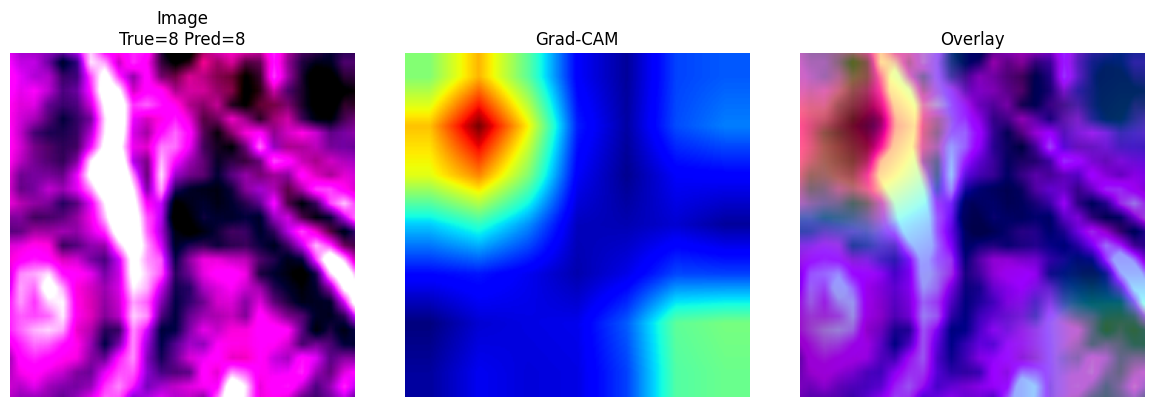

In [56]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# upsample de la heatmap à la taille de l'image
cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
cam_up = F.interpolate(cam_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_up = cam_up.squeeze().cpu().numpy()

# image pour affichage
img_np = image.permute(1, 2, 0).cpu().numpy()

# affichage
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={label.item()} Pred={pred_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_up, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
# Grad-CAM pour la classe vraie
cam_true, _, _ = compute_gradcam(resnet18, image_tensor, class_idx=int(label.item()))

/tmp/ipykernel_7628/4050268158.py:2: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



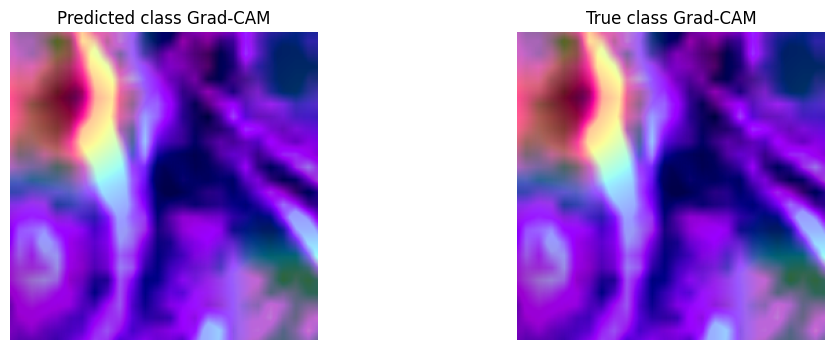

In [58]:
# upsample
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()
cam_true_up = F.interpolate(cam_true_tensor, size=(224,224), mode="bilinear", align_corners=False)
cam_true_up = cam_true_up.squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Predicted class Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("True class Grad-CAM")
plt.axis("off")

plt.show()

Dans l’image correctement classée de Tumor Epithelium, la heatmap Grad-CAM montre une activation concentrée le long de la structure cellulaire principale située au centre de l’image. Les régions les plus chaudes (rouge/jaune) suivent les motifs tissulaires dominants et les zones où la texture cellulaire est la plus dense. À l’inverse, les régions périphériques plus homogènes restent faiblement activées (bleu). Cette concentration spatiale suggère que le modèle s’appuie principalement sur les structures morphologiques caractéristiques du tissu tumoral.

Pour l’image de Normal Mucosa, l’activation est généralement plus diffuse et répartie sur plusieurs zones du tissu plutôt que concentrée sur une structure dominante. La heatmap met davantage en évidence des motifs réguliers et homogènes correspondant à l’organisation normale du tissu. Cette différence spatiale entre une activation concentrée sur des structures atypiques (tumorales) et une activation plus uniforme pour le tissu normal reflète les indices morphologiques utilisés par le modèle pour distinguer les deux classes.

In [59]:
# Trouver une image mal classée dans le test set

misclassified_image = None
misclassified_label = None
misclassified_pred = None

resnet18.eval()

for img, label in test_dataset_resnet:

    x = img.unsqueeze(0).to(device)
    y = int(label.item())

    with torch.no_grad():
        outputs = resnet18(x)
        pred = torch.argmax(outputs, dim=1).item()

    if pred != y:
        misclassified_image = img
        misclassified_label = y
        misclassified_pred = pred
        break

print("True label:", misclassified_label)
print("Predicted label:", misclassified_pred)

True label: 0
Predicted label: 5


/tmp/ipykernel_7628/1779192746.py:12: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



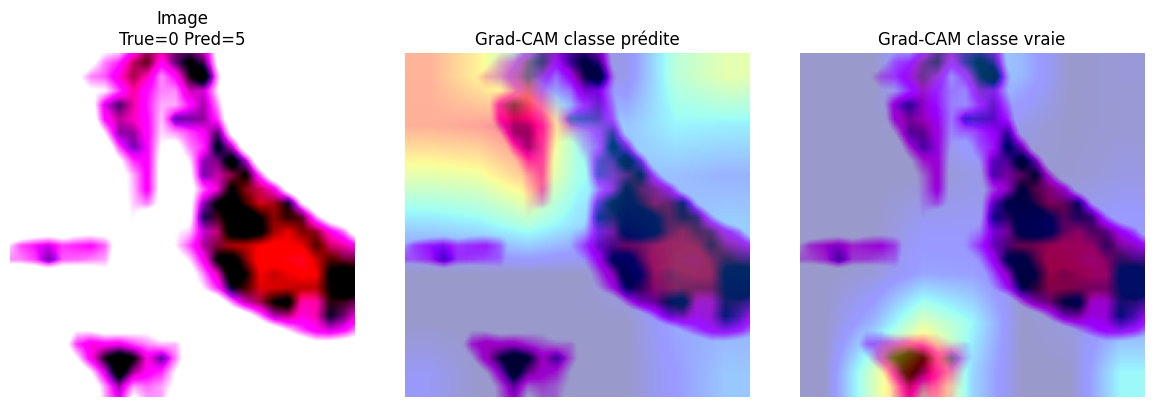

In [60]:
# Grad-CAM sur une image mal classée : classe prédite vs classe vraie

misclassified_tensor = misclassified_image.unsqueeze(0).to(device)

cam_pred, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_pred)
cam_true, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_label)

# Upsample des heatmaps
cam_pred_tensor = torch.tensor(cam_pred).unsqueeze(0).unsqueeze(0).float()
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()

cam_pred_up = F.interpolate(cam_pred_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_true_up = F.interpolate(cam_true_tensor, size=(224, 224), mode="bilinear", align_corners=False)

cam_pred_up = cam_pred_up.squeeze().cpu().numpy()
cam_true_up = cam_true_up.squeeze().cpu().numpy()

img_np = misclassified_image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={misclassified_label} Pred={misclassified_pred}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_np)
plt.imshow(cam_pred_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe prédite")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe vraie")
plt.axis("off")

plt.tight_layout()
plt.show()

Pour interpréter une erreur du modèle, nous avons utilisé Grad-CAM sur une image mal classée.
Nous comparons la carte d’activation associée à la classe prédite avec celle associée à la classe vraie.
Cela permet de voir si le modèle s’est trompé en se concentrant sur de mauvaises régions, ou si les indices visuels entre les deux classes sont réellement ambigus.

Ici, le modèle semble s’appuyer surtout sur une structure dominante de l’image qui lui évoque à tort la classe smooth muscle, alors que les indices pertinents pour la classe réelle adipose sont soit plus faibles, soit moins bien exploités.

la comparaison entre la carte associée à la classe prédite et celle associée à la classe vraie montre que le réseau s’appuie sur des zones pertinentes de l’image, mais les interprète dans le sens d’une classe concurrente. Cette analyse suggère que certaines erreurs proviennent d’une proximité visuelle réelle entre classes plutôt que d’un comportement totalement arbitraire.





# **Partie 7**

| Modèle                         | Architecture                     | Nombre de paramètres | Accuracy test | Temps d’entraînement (approx.) |
| ------------------------------ | -------------------------------- | -------------------- | ------------- | ------------------------------ |
| MLP (baseline)                 | Réseau fully connected           | 670,473              | 13.60%        | Faible                         |
| CNN                            | CNN (from scratch)               | 94,857               | 83.30%        | Moyen                          |
| ResNet18 (fine-tuning complet) | Transfer learning                | 11,181,129           | 90.04%        | Élevé                          |
| ViT (patch size = 7)           | Transformer (Vision Transformer) | 544,137              | 90.42%        | Moyen à élevé                  |


Le tableau comparatif met en évidence des différences nettes entre les architectures en termes de performance et d’efficacité. Le MLP, bien qu’ayant un nombre relativement élevé de paramètres, obtient des résultats très faibles, ce qui s’explique par son incapacité à exploiter la structure spatiale des images. À l’inverse, le CNN parvient à capturer efficacement les motifs locaux grâce aux convolutions, ce qui lui permet d’atteindre une bonne performance tout en restant peu coûteux en paramètres. Le modèle ResNet18, basé sur le transfer learning, améliore encore les performances en bénéficiant de représentations pré-entraînées, mais au prix d’un coût computationnel plus élevé. Enfin, le Vision Transformer (ViT) atteint une précision comparable à celle de ResNet avec un nombre de paramètres plus modéré, ce qui en fait une alternative intéressante. Cependant, ses performances dépendent fortement de choix architecturaux spécifiques, comme la taille des patches ou l’utilisation des positional encodings, ce qui le rend plus sensible à la configuration que les CNNs.

**le tradeof des modeles**

| Modèle                     | Accuracy | # Paramètres | Coût computationnel | Avantages                                                            | Limites                                                        | Quand l’utiliser                            |
| -------------------------- | -------- | ------------ | ------------------- | -------------------------------------------------------------------- | -------------------------------------------------------------- | ------------------------------------------- |
| **MLP**                    | ~13.6%   | 670k         | Faible              | Simple à implémenter                                                 | Ne capture pas la structure spatiale → très faible performance | Baseline uniquement                         |
| **CNN**                    | ~83.3%   | 94k          | Modéré              | Très bon rapport performance / paramètres, capture les motifs locaux | Moins performant que modèles pré-entraînés                     | Données limitées + ressources modestes      |
| **ResNet18 (fine-tuning)** | ~90.0%   | 11.1M        | Élevé               | Haute performance, robuste, transfer learning efficace               | Très lourd, dépend d’ImageNet                                  | Dataset petit/moyen + besoin de performance |
| **ViT (patch size 7)**     | ~90.4%   | 544k         | Moyen–élevé         | Capture relations globales, bon compromis perf / paramètres          | Sensible à la configuration (patch, PE)                        | Si architecture bien maîtrisée              |


Le MLP est à utiliser uniquement comme baseline ou pour des tâches très simples ne nécessitant pas la prise en compte de la structure spatiale, car il est inadapté à la classification d’images.

Le CNN (from scratch) est un bon choix lorsque l’on dispose de ressources computationnelles limitées et d’un dataset de taille modérée, offrant un excellent compromis entre performance et complexité.

Le transfer learning avec ResNet18 est à privilégier lorsque le dataset est petit ou moyen et que l’on recherche une performance élevée rapidement, au prix d’un coût computationnel plus important.

Le Vision Transformer (ViT) est pertinent lorsque l’on souhaite capturer des relations globales dans les images et que l’architecture est bien maîtrisée, offrant un bon compromis performance / paramètres mais restant plus sensible aux choix de configuration.

Les modèles les plus efficaces en termes d’utilisation des données sont le CNN et le ResNet18 en transfer learning. Le CNN parvient à atteindre une bonne performance (environ 83%) avec relativement peu de paramètres (environ 94k), en exploitant efficacement les structures locales des images. Le ResNet18 est encore plus performant (environ 90%), car il bénéficie de représentations pré-entraînées, ce qui lui permet de bien généraliser même avec un dataset de taille limitée. À l’inverse, le MLP est le moins data-efficient, avec une très faible performance (environ 13.6%), car il ne capture pas la structure spatiale et nécessite beaucoup plus de données pour apprendre efficacement. Le Vision Transformer (ViT) montre une bonne performance (environ 90.4%), mais sa data efficiency dépend fortement de sa configuration : avec un patch size adapté (7), il devient compétitif, mais il reste globalement plus sensible à la quantité de données que les CNNs. Enfin, la résolution des images (28×28) joue un rôle important : elle favorise les CNNs, qui exploitent efficacement les détails locaux même à basse résolution, tandis que les ViTs peuvent perdre de l’information si les patches sont trop grands (comme avec un patch size de 14), ce qui dégrade les performances.

le modèle ResNet18 fine-tuné. Bien que le Vision Transformer obtienne une performance légèrement supérieure, le ResNet est généralement plus robuste, mieux compris et plus stable, notamment grâce au transfer learning. Il offre un bon compromis entre performance élevée, fiabilité et interprétabilité relative, ce qui est essentiel dans un contexte médical où les décisions doivent être justifiables.

Avant une utilisation réelle en clinique, plusieurs étapes supplémentaires sont indispensables. Il faudrait d’abord valider le modèle sur des données externes issues d’autres hôpitaux afin de vérifier sa capacité de généralisation. Ensuite, une évaluation clinique rigoureuse devrait être menée, idéalement sous forme d’études prospectives avec des professionnels de santé. Il serait également nécessaire d’intégrer des outils d’interprétabilité (comme Grad-CAM) pour permettre aux pathologistes de comprendre les décisions du modèle. Par ailleurs, des considérations réglementaires doivent être prises en compte, avec des certifications adaptées aux dispositifs médicaux. Enfin, le modèle devrait être intégré dans un workflow clinique avec une interface claire et des mécanismes de contrôle humain, afin qu’il reste un outil d’aide à la décision et non un substitut au jugement médical.

L’utilisation de l’IA pour la classification de tissus cancéreux comporte plusieurs risques importants. Le plus critique est celui des faux négatifs, où un tissu cancéreux est classé comme sain, ce qui peut retarder un diagnostic et compromettre la prise en charge du patient. Le déséquilibre des classes constitue également un enjeu majeur : si certaines catégories sont sous-représentées dans les données d’entraînement, le modèle aura tendance à moins bien les reconnaître, ce qui peut entraîner des performances inégales selon les types de tissus. Par ailleurs, les biais présents dans le dataset, liés par exemple à l’origine des données, aux conditions d’acquisition ou à la diversité des patients, peuvent limiter la capacité du modèle à généraliser et conduire à des erreurs systématiques sur certaines populations. Enfin, le manque d’interprétabilité des modèles, en particulier des architectures complexes comme les réseaux profonds, pose un problème de confiance et d’acceptabilité : les professionnels de santé doivent pouvoir comprendre et justifier les décisions du modèle. Ces risques soulignent que ces systèmes doivent rester des outils d’aide à la décision, utilisés avec prudence et accompagnés de validations rigoureuses.

Q.7.2

Un résultat inattendu observé au cours de ce projet concerne l’impact du positional encoding dans le modèle Vision Transformer. Initialement, nous nous attendions à ce que l’ajout de positional encoding améliore les performances, car il permet d’introduire une information spatiale essentielle pour modéliser la structure des images. Dans les architectures Transformer, cette information est généralement cruciale pour préserver l’ordre et les relations entre les tokens.

Cependant, dans nos expériences, la suppression du positional encoding a conduit à de meilleures performances. Le modèle sans positional encoding a atteint une accuracy de 92.62%, contre 90.42% avec positional encoding. Ce résultat est surprenant, car il contredit l’intuition classique.

Une explication possible réside dans la nature des images médicales utilisées. Contrairement aux images naturelles, où la position des objets joue un rôle important, les images histologiques reposent davantage sur des motifs locaux et des textures, dont la position absolue est moins informative. De plus, la faible résolution des images (28×28) et la taille des patches limitent déjà l’information spatiale disponible. Dans ce contexte, le positional encoding peut introduire du bruit ou des contraintes inutiles, alors que le modèle parvient à capturer les structures pertinentes sans cette information explicite. Ce résultat suggère que, pour certaines tâches médicales à basse résolution, la modélisation explicite de la position n’est pas toujours nécessaire et peut même dégrader les performances.

Q.7.3

Cette proposition nuirait très probablement aux performances du modèle. Le label smoothing classique consiste à remplacer les labels one-hot par une distribution légèrement adoucie (par exemple 0.9 pour la classe correcte et 0.1 réparti sur les autres), ce qui aide à éviter le sur-apprentissage et améliore la calibration des probabilités. En revanche, remplacer les labels par des vecteurs aléatoires uniformes revient à injecter du bruit non informatif dans les cibles d’entraînement. Dans ce cas, le modèle ne reçoit plus de signal clair sur la classe correcte et ne peut plus apprendre une correspondance fiable entre les entrées et les sorties.

Concrètement, cela dégraderait fortement la convergence, car la fonction de perte serait minimisée en apprenant des associations arbitraires plutôt qu’en capturant les véritables structures des données. On peut s’attendre à une baisse significative de l’accuracy et à une instabilité de l’entraînement. Contrairement au label smoothing standard, qui conserve l’information sur la classe correcte tout en régularisant, ce “random label smoothing” détruit cette information essentielle. Ainsi, il ne s’agit pas d’une technique de régularisation bénéfique, mais plutôt d’un bruit nuisible qui empêche le modèle d’apprendre correctement.